<div style="text-align: right; font-size: 2em"> <b> F78DS Data Science Life Cycle </b> </div>
<br>
<div style="text-align: right; font-size: 2em"> <b> Coursework 2 </b> </div>
<br>
<div style="text-align: right"> Renee Lim Ee Ling </div>
<div style="text-align: right"> H00488258 </div>
<div style="text-align: right"> 1st <sup>th</sup> April 2025 </div>

## Introduction
In this coursework, machine learning techniques are used to predict the scores of essays based on data from `F78DS-Essay-Features.csv`, which consists of data regarding essay features and their corresponding scores, this makes it labelled data as the dataset contains both input and output variables. Hance, **supervised machine learning** is used.

To enhance model performance, feature selection will be applied. After that, The data will be split into training data and validation data. Training data is used to train the model and validation data is used to evaluate the model's performance.  The split data will then be normalized using `StandardScaler()`. Since we are working with labelled data, we can compare the predicted values to the actual values. This helps us to evaluate the model's performance and fine-tune the hyperparameters for better results.

**Naive Bayes**, **Random Forest** and **xTreme Gradient Boost** are the models used in this coursework to make predictions of essay scores ranging from 1 to 6.
To assess the models, a **confusion matrix** and **Quadratic Weighted Kappa (QWK)** are used as evaluation metrics for the predictive models that were built.

Finally, after all the models are built, we will ensemble all of the models to build a more robust predictive model and use it to predict the test dataset provided on Kaggle.

## Importing libraries and reading data

The first step is to import the necessary libraries :


  **Pandas** - to analyze, clean, explore, and manipulate the data

  
  **Numpy**  - for mathematical operations such as statistical analysis

In [5]:
import pandas as pd
import numpy as np

Now, we use **pandas**'s `read_csv` function to convert the CSV file into a DataFrame then use `head`, `shape`, and `describe` to inspect the data

In [7]:
essays = pd.read_csv('F78DS-Essay-Features.csv')
essays.head()

,essayid,chars,words,commas,apostrophes,punctuations,avg_word_length,sentences,questions,avg_word_sentence,POS,POS/total_words,prompt_words,prompt_words/total_words,synonym_words,synonym_words/total_words,unstemmed,stemmed,score
0,1457,2153,426,14,6,0,5.053991,16,0,26.625000,423.995272,0.995294,207,0.485915,105,0.246479,424,412,4
1,503,1480,292,9,7,0,5.068493,11,0,26.545455,290.993103,0.996552,148,0.506849,77,0.263699,356,345,4
2,253,3964,849,19,26,1,4.669022,49,2,17.326531,843.990544,0.994100,285,0.335689,130,0.153121,750,750,4
3,107,988,210,8,7,0,4.704762,12,0,17.500000,207.653784,0.988828,112,0.533333,62,0.295238,217,209,3
4,1450,3139,600,13,8,0,5.231667,24,1,25.000000,594.652150,0.991087,255,0.425000,165,0.275000,702,677,4


In [8]:
essays.shape

(1332, 19)

In [9]:
essays.describe()

,essayid,chars,words,commas,apostrophes,punctuations,avg_word_length,sentences,questions,avg_word_sentence,POS,POS/total_words,prompt_words,prompt_words/total_words,synonym_words,synonym_words/total_words,unstemmed,stemmed,score
count,1332.00000,1332.000000,1332.000000,1332.000000,1332.000000,1332.00000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.00000,1332.000000,1332.000000,1332.000000,1332.000000
mean,905.27027,2101.745495,424.485736,14.667417,8.141141,0.47973,4.939762,19.704204,1.222973,23.884687,420.596542,0.989935,198.913664,0.469164,110.16967,0.263846,468.987988,455.507508,3.427177
std,526.68760,865.963750,171.873730,10.920781,6.124520,1.27168,0.231071,19.202731,1.847446,11.160020,170.985111,0.007308,82.729266,0.052466,43.96192,0.038870,159.447449,155.751220,0.774275
min,0.00000,169.000000,36.000000,0.000000,2.000000,0.00000,2.231322,0.000000,0.000000,1.084112,35.647059,0.924771,14.000000,0.288889,11.00000,0.027299,48.000000,50.000000,1.000000
25%,442.75000,1527.250000,310.000000,7.000000,4.000000,0.00000,4.791679,13.000000,0.000000,19.142857,305.406284,0.987758,144.000000,0.435709,81.00000,0.238423,361.000000,350.750000,3.000000
50%,914.50000,2029.500000,411.000000,13.000000,6.000000,0.00000,4.946059,18.000000,1.000000,22.030331,406.982869,0.991572,193.000000,0.465852,107.50000,0.262872,463.000000,448.000000,3.000000
75%,1369.75000,2613.500000,525.000000,21.000000,11.000000,0.00000,5.092938,24.000000,2.000000,26.048234,520.739458,0.994425,246.000000,0.500000,134.00000,0.288277,581.000000,561.250000,4.000000
max,1799.00000,6142.000000,1170.000000,72.000000,51.000000,26.00000,5.681429,642.000000,17.000000,303.000000,1158.984563,1.000000,669.000000,0.961207,355.00000,0.465517,750.000000,750.000000,6.000000


Next, we will visualise the output by plotting a bar chart. This is done by importing the **matplotlib** library and **seaborn** library then use `sns.countplot` to show the count of each essay score.

**matplotlib** - for data visualization such as generating line plots, bar charts, scatter plots, and other basic visualizations.

**seaborn** - to make statistical plots with enhanced visual appeal and simplicity

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

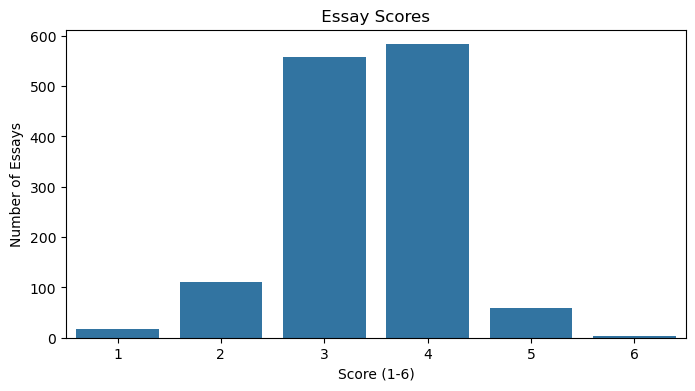

In [12]:
plt.figure(figsize=(8, 4))
sns.countplot(x='score', data=essays)
plt.title(" Essay Scores ")
plt.xlabel("Score (1-6)")
plt.ylabel("Number of Essays")
plt.show()

Based on the output, the CSV file contains 1332 essays and 19 essay features with a mean score of 3.42. 

From the bar chart, we can see that there is clustering around scores 3 and 4, with very few essays receiving a score on the extreme
ends, namely 1 and 6. This suggests that the data is imbalanced.

The data was derived from a set of essays and is used to describe the essay features in numeric information, meaning that natural language processing (NLP) was used to help computer programmes and predictive models better understand human language. 

## Surpervised learning

There are two types of machine learning, namely supervised machine learning and unsupervised machine learning. In this coursework, we will be using supervised machine learning.

Supervised machine learning is a machine learning technique where algorithms are trained using labelled data, meaning each input has a corresponding output. Using these input-output pairs, the algorithm learns and is able to predict the outcomes of unseen data based on the patterns learned from the labelled examples. The labelled data serves as the 'ground truth' and is used as the objective standard to train and assess a given model.

There are two common types of models in supervised machine learning, those are regression models (predicts continuous values) and classification models (predicts discrete values).

Examples of regression models: Linear regression, Polynomial Regression, Support Vector regression

Examples of classification models: Naive Bayes, Random Forest, Support Vector Machines

The labelled dataset will be split into training data and validation data. The model will use the training data to learn and make predictions. Then validation data is used to provide unbiased evaluation of the model so we can fine-tune the hyperparameters.

Finally, we use the test dataset, which is an unseen subset of the original dataset, to evaluate the model's performance.

## Features Selection

Before building the model, we need to identify the features (ie input variables) and the label (ie output variable). In this case, the label is the score of each essay and will be named '**y**', this is the dependent variable. Then, the other variables are the features of the essay which will be labelled '**X**', these are the independent variables.

In [16]:
X = essays.drop(['score'], axis=1)
y = essays['score']

To enhance the model performance, feature selection is carried out. Only relevent features, meaning input variables that have a significant correlation to the output variable will be chosen to train the model for better predictions.

To find out how strong the correlation of each essay feature is in relation to the score, the function `corr` is used. In addition, Spearman's correlation is used to assess the strength and direction of a monotonic relationship since the essay scores are ordinal and this also ensures that clustering doesn’t skew results.

In [18]:
spearman_corr = essays.corr(method='spearman')['score'].sort_values(ascending=False)

print("Top features predicting score:")
print(spearman_corr)

Top features predicting score:
score                        1.000000
chars                        0.685272
stemmed                      0.673720
unstemmed                    0.671587
POS                          0.662971
words                        0.661766
prompt_words                 0.656834
sentences                    0.593211
synonym_words                0.576702
commas                       0.551711
apostrophes                  0.344668
avg_word_length              0.312069
questions                    0.284039
POS/total_words              0.266051
punctuations                 0.217691
prompt_words/total_words     0.054713
essayid                      0.026410
avg_word_sentence           -0.026498
synonym_words/total_words   -0.301870
Name: score, dtype: float64


Only essay features that have a moderate to strong correlation (|x| > 0.3) with the essay scores will be selected. This means that the following essay features will be dropped: 'apostrophes', 'avg_word_length', 'questions', 'POS/total_words', 'punctuations', 'prompt_words/total_words', 'essayid', 'avg_word_length', 'synonym_words/total_words'

In [20]:
X = X.drop(columns=['punctuations', 'POS/total_words', 'questions', 'prompt_words/total_words', 'essayid', 'avg_word_sentence'])

Now we will use `hist` to plot a histogram which will show us the distribution of the features that were selected.

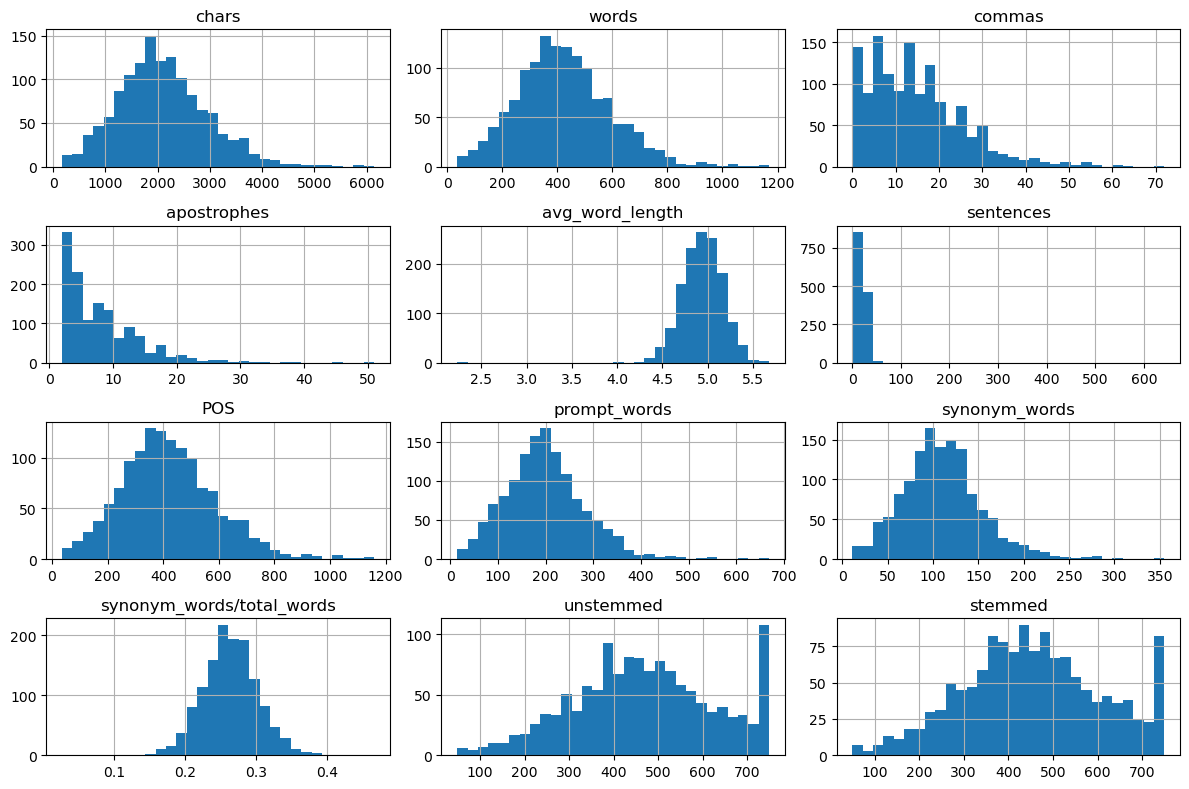

In [22]:
X.hist(figsize=(12, 8), bins=30)

plt.tight_layout()
plt.show()

Based on the output, we can see that some of the input variables show different levels of skewedness. It can also be observed that some input variables have very different scales (eg `chars` and `avg_word_length`). This will be addressed in later parts.

## Splitting data

The data will be split into training data and validation data. Once again, training data is used to teach the model to recognize patterns and make  whereas validation data is used to evaluate the model performance and fine-tune the model's hyperparameters.

Since the dataset contains information 1332 essays, the dataset is reasonably large so it will be split into 85% training data and 15% validation data. To do this, we will import the **Scikit-learn** library, which is used for a wide range of machine learning tasks including classification, regression, clustering, and data preprocessing. In particular, we will be using the function `train_test_split` from the `model_selection` module of **Scikit-learn** to randomly split the data.

Furthermore, the function `random_state` is to ensure random splitting of the data and ensure reproducibility whereas `stratify` is to ensure data consistency since the data is clustered around scores 3 and 4, with fewer examples of scores 1 and 6. `stratify` works by sorting the output variables equally between the training and validation data, this helps maintain the same proportion of each score in both datasets. By doing so, it prevents underrepresented classes from being excluded and ensures the model sees a balanced variety of scores during training and validation.

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=4, stratify=y)

## Classification

There are two types of classification, that is **Binary Classification** and **Multi-Class Classification**.

In **Binary Classification**, output data is categorized into one of two distinct classes or categories, such as "yes" or "no", '1' or '0', 'positive' or 'negative'. For example, filtering spam emails.

In **Multi-Class Classification**, output data is categorized into one of three or more classes and is more complex than Binary Classification. For example, image recognition.

Below are some of the key differences between Binary Classification and Multi-Class Classification:

1. **Number of Classes**: Binary Classification only involves only two classes whereas Multi-Class Classification involves three or more classes.
2. **Complexity**: Due to the larger number of classes involed, Multi-Class Classification is more complex than Binary Classification. This is because Binary Classfication only has to categorise output data into one of two classes (eg 0 or 1), Multi-Class Classification involves numerous classes which requires the model to learn distinct decision boundaries and handle potential class imbalances or overlaps in the dataset.
3. **Evaluation Metric**: Even though both Binary Classification and Multi-Class Classification uses evaluation metrics such as accuracy, precision, recall, and F1 score, the interpretation of these metrics may vary slightly. For example, Binary Classification measures accuracy by
calculating (Number of True Positive + Number of True Negative) / Total. Meanwhile, Multi-Class Classification measures accuracy using (Total correct predictions) / (Total predictions) 

## Data Normalisation/Data Scaling

**Data normalization** or **data scaling** is an important pre-processing step for many machine learning algorithms as it ensures data uniformity of numerical data. This is especially important for algorithms that are sensitive to feature scaling or when the distribution of that data is unknown.

Thus, before building the model, we will first normalise/scale the data in order to ensure that the learning process is not dominated by a single variable. This is because the data may have features (input variables) with scales that vary widely, so pre-processing techniques such as normalisation is used to transform the data to a specific range (eg 0 to 1) in order to ensure the model works well and interprets features more precisely as well as have good training convergence speed. It is also important to note that data normalisation is done after the train-test split to prevent data leakage.


Examples of different ways to do data normalisation/scaling:

`StandardScaler()`: Normalize each feature (input variable) so that each has a mean of 0 and standard deviation of 1. Useful for linear models such as Linear Regression.

`MinMaxScaler()`  : Transforms the data so that every value falls between 0 and 1 and is more sensitive to outliers because the scale is heavily influenced by the extreme maximum and minimum values. Ueful for algorithms that are sensitive to the scale of the features such as Neural Networks and K-Nearest Neighbors (KNN).

Since we will mainly be doing classification tasks, `StandardScaler()` will be used. To do that, we import StandardScaler from the module **sklearn.preprocessing** found in the **Scikit-learn** library.

In [29]:
from sklearn.preprocessing import StandardScaler

The function `fit_transform()` is used on the training dataset to calculate the mean and standard deviation for each column then  scale each value using these statistics. On the other hand, `transform()` is used to scale the validation dataset using the mean and standard deviation that were computed from the training dataset.

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Naive Bayes

**Naive Bayes** is a supervised machine learning algorithm that uses Bayes' Theorem for classification tasks to find probabilities. Each feature (input variable) of the dataset is assumed to be independent of each other. Predictions (output variable) are made based on the probabilities of each feature.

There are four models for Naive Bayes:

1. **Gaussian Naive Bayes** - assumes that feature values follow a gaussian distribution
2. **Multinomial Naive Bayes** - predicts the class of a document based on the frequencies of words (features) within it, useful for text classification tasks
3. **Bernouille Naive Bayes** -  useful for datasets with binary features where features are either present (1) or absent (0) (eg spam detection)
4. **Categorical Naive Bayes** - useful for datasets with categorical features. The categorical data have to be converted into numerical data using ordical encoding.

Since we have already shown the histograms for each input variable (refer to top), we can see that the features are mostly continuous and have a bell-shaped curve. Hence, **Gaussian Naive Bayes** will be used. To do this, we will use the function `GaussianNB()` from the module **sklearn.naive_bayes** to build the model.


However, before building the model, we first need to find out what configuration of hyperparameters is most suitable for the model to make more accurate predictions. The hyperparameter for the `GaussianNB` model is `var_smoothing`, which adds a small value to variances to prevent division by zero probability errors in the event a feature value doesn't appear in the training data for a particular class. This is called a smoothing factor.

Since it is tedious to manually compute the best hyperparameters, a hyperparameter tuning technique called **grid search** is utilised to automate this process. The function `GridSearchCV()` from the module **sklaern.model_selection** is imported in order to systematically explore a predefined set of hyperparameter values by training and evaluating the model on each possible combination to find the one that performs the best.

In [34]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

In [35]:
gnb = GaussianNB()
param_grid = {'var_smoothing': np.logspace(-12, -6, num=20)}
grid_search = GridSearchCV(gnb, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("Best var_smoothing:", grid_search.best_params_['var_smoothing'])

Best var_smoothing: 1e-12


In the `GaussianNB` model, the default for `var_smoothing` is 1e-09. If the model overfits*, we can try increasing the setting for `var_smoothing`. If the model underfits*, we can try decreasing the setting for `var_smoothing`. 

***Overfitting** occurs when a model learns the training data too well, including noise and irrelevant details, leading to poor generalization to new data. This causes a high variance each time the model makes a prediction, causing the results to vary widely.

***Underfitting** occurs when a model is too simple and fails to capture the underlying patterns in the data and is often associated with a high bias (especially with low variance), leading to the model making innaccurate predictions.

In the function `GridSearchCV()`, `cv=3` refers to 3-fold cross validation. Basically, the dataset is split into three parts, with each part serving as a test set in one of the three iterations, ensuring each segment is used for both training and validation. The number 3 is chosen because `y_train` has only 3 members. This helps to evaluate the model performance by reducing overfitting and underfitting.


Here, `best_params_` is used to determine the best setting for `var_smoothing`. Based on the outcome, it seems like the best setting for `var_smoothing` is 1e-12.

But if you notice, the `scoring` that was used in the grid search is `accuracy`. However, for this coursework, we want to use **Quadratic Weighted Kappa (QWK)** to evaluate the model performance. This will be explained in the next part.


## Quadratic Weighted Kappa (QWK). 

**Quadratic Weighted Kappa (QWK)** is a statistical metric that measures agreement between two raters for ordinal categories (eg essay scores 1–6). Unlike simple accuracy or other metrics such as Cohen's Kappa, QWK takes into account not only whether the two raters agree but also how far apart their ratings are, it does so by introducing a quadratic penalty for disagreements that are farther apart. This makes it particularly useful for situations where the ratings are ordered, but the exact differences between them are important. QWK scores ranges from -1 to 1.

-1 : agreement is worse than chance

0: agreement is based on random chance

1: perfect agreement

The Quadratic Weighted Kappa (QWK) score is calculated using the following formula:


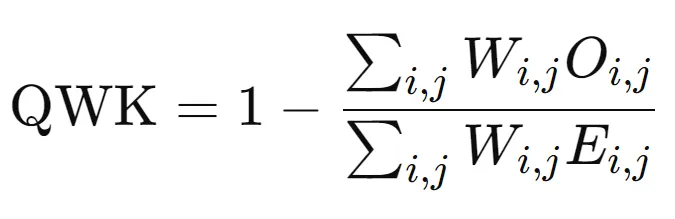
Source: Medium.com

where

W
i,j
​
  = quadratic weight (i-j)^2
 

O
i
,
j
​
  = observed agreement counts

E
i
,
j
​
  = expected chance counts



Since the **scikit-learn** doesn't have a built-in function for QWK scoring, we'll have to define one by first importing `make_scorer` and `cohen_kappa_score`* from **sklearn.metrics**.

*Cohen Kappa measures the agreement between two raters on a categorical scale. It does so by comparing the observed agreement between two raters with the agreement expected by chance.

In [42]:
from sklearn.metrics import make_scorer, cohen_kappa_score

In [43]:
def qwk_score(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

qwk_scorer = make_scorer(qwk_score, greater_is_better=True)

Now we can adjust our model by changing `scoring` to `qwk_score`.

In [45]:
gnb = GaussianNB()
param_grid = {'var_smoothing': np.logspace(-12, -6, num=20)}
grid_search = GridSearchCV(gnb, param_grid, cv=3, scoring=qwk_scorer)
grid_search.fit(X_train_scaled, y_train)

print("Best var_smoothing:", grid_search.best_params_['var_smoothing'])

Best var_smoothing: 1e-12


The result shows that 1e-12 is the best setting for `var_smoothing`. Using this information, we will proceed to build the model.

In [47]:
gnb = GaussianNB(var_smoothing= 1e-12)
gnb.fit(X_train_scaled, y_train)

GaussianNB(var_smoothing=1e-12)

The model is then used to predict the essay scores for the validation dataset. After that, a **confusion matrix** is used to evaluate the model's performance.

In [49]:
y_pred_gnb = gnb.predict(X_val_scaled)

A **confusion matrix** evaluates the performance of a classification model by comparing predicted values against actual values, showing the counts of true positives, true negatives, false positives, and false negatives. 

To build the confusion matrix, we first import`confusion_matrix` from **sklearn.metrics** which will be used on the validation data (`y_val`) and predicted data (`y_pred`), this gives us a 6x6 confusion matrix since the essay scores ranges from 1 to 6.

In [51]:
from sklearn.metrics import confusion_matrix

In [52]:
cm = confusion_matrix(y_val, y_pred_gnb)
cm

array([[ 2,  1,  0,  0,  0,  0],
       [12,  2,  2,  0,  0,  0],
       [ 1,  9, 61, 12,  1,  0],
       [ 0,  0, 24, 43, 20,  0],
       [ 0,  0,  1,  4,  4,  0],
       [ 0,  0,  0,  1,  0,  0]], dtype=int64)

To help visualise the outcome, a heatmap of the confusion matrix is constructed using `sns.heatmap`.

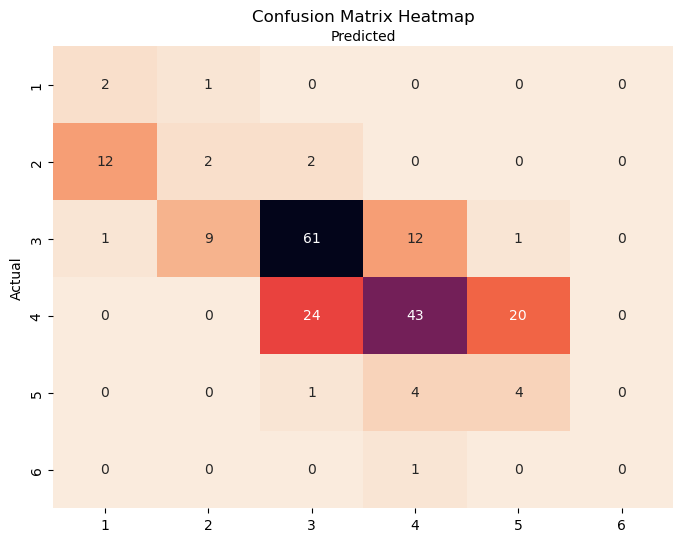

In [54]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', cbar=False, xticklabels = np.arange(1, 7), yticklabels = np.arange(1, 7))

plt.gca().xaxis.set_label_position('top')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The horizontal axis of the confusion matrix tells us the predicted score whereas the vertical axis tells us the actual score. Hence, to count how many correct predictions were made by the model, we simply look at the diagonal line. For example, [3,3] tells us that the model accurately predicted essays with a score of 3 for a total of 61 times. By looking at [3,2], it tells us that the model incorrectly predicted a score of 2 for an essay that has an actual score of 3 for a total of 9 times. 

Based on the results, the model accurately predicted the scores of 112 ( 2+2+61+43+4 = 112 ) essays. 

Now we compute the **Quadratic Weighted Kappa (QWK)** score to evaluate the model's performance.

In [56]:
qwk_gnb = cohen_kappa_score(y_val, y_pred_gnb, weights='quadratic')
print(f"Quadratic Weighted Kappa (QWK): {qwk_gnb}")

Quadratic Weighted Kappa (QWK): 0.7001679059726553


This shows that the agreement between the actual scores and the predicted scores by the model is approximately 0.7001679.

## Random Forest
A second machine learning model will be used to help us make better predictions on the essay scores based on the given data.

**Random Forest** is a supervised machine learning algorithm that uses an ensemble of decision trees* and combines their predictions to make a final prediction. This is to improve accuracy and reduce overfitting. Random Forest is widely used for both classification and regression tasks.

*A Decision Tree is a supervised machine learning algorithm that makes predictions by splitting the data into branches based on feature values, forming a tree-like structure. This helps to identify the best course of action by mapping out different choices and their potential consequence. Decision Tree is widely used for classification and regression tasks.

RandomForest works by randomly selecting multiple subsets of the training data to train different decision trees. This is a process known as bootstrap sampling or bagging. The subsets of the training data are generated with replacement, meaning same data may appear more than once in a subset, while others may not appear at all. This helps to reduce variance and improve generalization.

Each Decision Tree is trained independently with different subsets of the training data to ensure random feature selection. 

For classfication tasks, the majority of the predictions from all Decision Trees are aggregated to make a more accurate final prediction. For regression tasks, the average of the predictions from all Decision Trees is used to make a make a more accurate final prediction.

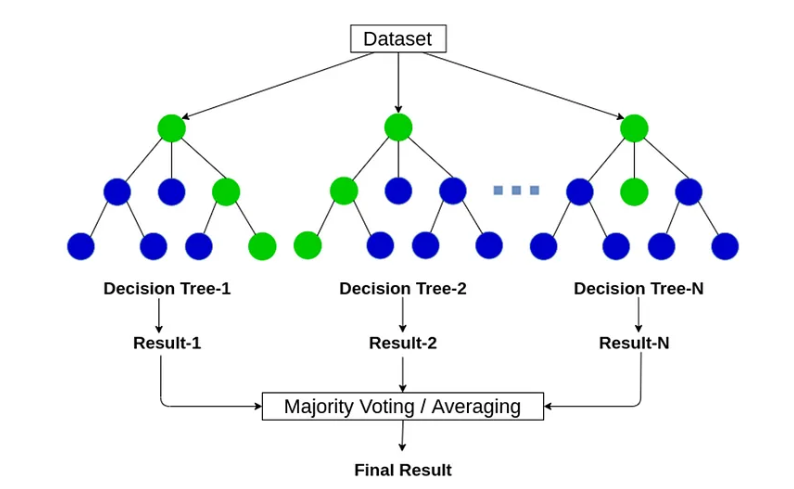
Source: Medium.com

There are five key hyperparameters that we will fine-tune to help improve the performance of the Random Forest model, those are:

1. `n_estimators`: Number of Decision Trees. Generally, more trees gives better performance, but may take more time to train
2. `max_depth`: Limits the maximum depth of the individual trees. Deep or complex trees may result in overfitting, but shallow or more simple trees have a risk of underfitting
3. `min_samples_split`: The minimum number of samples required to split a node. More splits results in deeper trees, fewer splits results in more shallow trees.
4. `min_samples_leaf`: The minimum number of samples required to be at a leaf node. A smaller value results in more leaves, thus variance is higher. A higher value results in fewer leaves, this reduces overfitting but may have a risk of underfitting.
5. `max_features`: Number of features to consider when making splits at each node. Using more features results in more information used per tree, but there is more correlation which may lead to overfitting. Using fewer features increases randomness and reduces overfitting.

Now we import `RandomForestClassifier` from the module **sklearn.ensemble**. Once again, `GridSearchCV()` and `best_params_` are utilised to determine the best values to fine-tune the hyperparameters for the Random Forest model. 
   

In [61]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 2, 4],
    'min_samples_split': [10, 12, 15],
    'min_samples_leaf': [2, 3, 4],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=4)

grid_search = GridSearchCV(rf, param_grid, cv=3, scoring=qwk_scorer, n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(grid_search.best_params_)

Fitting 3 folds for each of 162 candidates, totalling 486 fits
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 150}


Now we can build the Random Forest model using the best hyperparameters and use it to make predictions of the essay scores.

In [64]:
rf = RandomForestClassifier(
    n_estimators=150,      
    max_depth=None,          
    min_samples_split=10,    
    min_samples_leaf=3,    
    max_features='sqrt', 
    n_jobs=-1,              
    random_state=4,
)

rf.fit(X_train_scaled, y_train)  

y_pred_rf = rf.predict(X_val_scaled)

After that, we use a **confusion matrix** to summarize the results of the predictions then compute the **Quadratic Weighted Kappa (QWK)** score to evaluate the model's performance.

In [66]:
cm = confusion_matrix(y_val, y_pred_rf)
cm

array([[ 2,  1,  0,  0,  0,  0],
       [ 1, 11,  4,  0,  0,  0],
       [ 0,  1, 64, 18,  1,  0],
       [ 0,  0, 16, 69,  2,  0],
       [ 0,  0,  1,  7,  1,  0],
       [ 0,  0,  0,  1,  0,  0]], dtype=int64)

A heatmap is used to help visualise the confusion matrix.

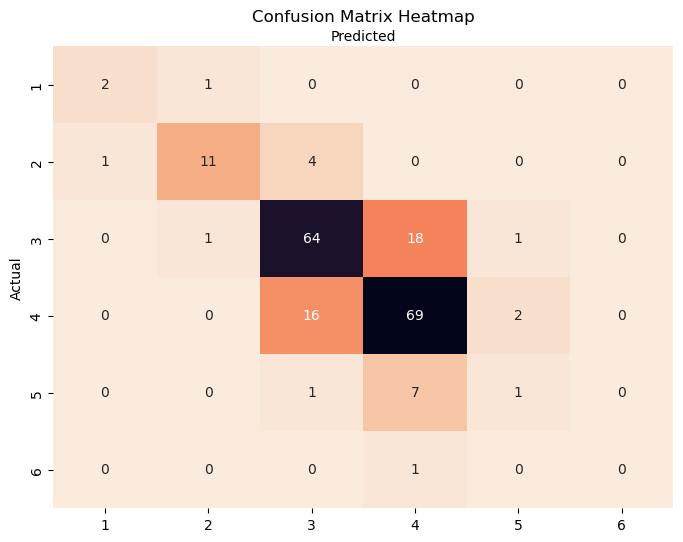

In [68]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', cbar=False, xticklabels = np.arange(1, 7), yticklabels = np.arange(1, 7))

plt.gca().xaxis.set_label_position('top')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The confusion matrix shows that the Random Forest model accurately predicted the scores of 147 (2+11+64+69+1 = 147) essays.

Now, we compute the **Quadratic Weighted Kappa (QWK)** score for the Random Forest model.

In [70]:
qwk_rf = cohen_kappa_score(y_val, y_pred_rf, weights='quadratic')
print(f"Quadratic Weighted Kappa (QWK): {qwk_rf}")

Quadratic Weighted Kappa (QWK): 0.7229174115123347


This shows that the agreement between the actual scores and the predicted scores by the model is approximately 0.722917.

## Naive Bayes vs Random Forest

The predictions by the Random Forest model received a QWK score of approximately 0.722917, not much higher than the Gaussian Naive Bayes model which got approximately 0.7001679. However, Random Forest accurately predicted the scores of 147 essays while Gaussian Naive Bayes only predicted the scores of 112 essays correctly. 

This suggests that even though Gaussian Naive Bayes predicted fewer essays correctly, it might have been more consistent in predicting the correct rating classes (especially for scores 3 and 4). This is because QWK measures the agreement between the predicted and actual scores while considering the distance between the predicted and actual ratings. 

Hence, it can be said that the predictions made using the Random Forest model is better than the Gaussian Naive Bayes model. However, since both models work differently, the results were expected to also differ. There are a few reasons why Random Forest had a better performance compared to Naive Bayes.

1. **Assumptions**: Naive Bayes assumes that all input variables (essay features) are independent of each other and have a linear relationship with the output variable (essay scores). On the other hand, Random Forest is a non-parametric model, meaning it doesn’t assume anything about the distribution of the data or the relationships between features. This helps it to work well with data that have complex and nonlinear relationships.

2. **Feature Distribution**: If the input variables (essay features) don’t follow a Gaussian distribution, 'GaussianNB' can perform poorly. Meanwhile, Random Forest has a better performance because it doesn't assume that the data follows a particular distribution.

3. **Complexity**: Random Forest is more complex as it is an ensemble of Decision Trees, helping it to model non-linear relationships between features. Thus, Random Forest is better at handling datasets with imbalanced data and involves feature importance. Naive Bayes is a simpler model and limited by the assumption of a linear relationship between features.


## XGBoost

**XGBoost (Xtreme Gradient Boosting)** is a supervised machine learning model that is similar to Random Forest but works in a different way, making it suitable for classification and regression tasks. XGBoost is an ensemble learning algorithm based on gradient boosting, which is a technique that combines multiple weak Decision Trees sequentially, using each new Decision Tree to correct the errors of the previous one. This helps to increase model performance, resulting in more accurate predictions.

While Random Forest is generally faster because it uses parallel tree building, XGBoost is usually has higher accuracy but may require more demanding hyperparameter tuning and has a higher risk of overfitting.

We will be building an XGBoost model to evaluate it's performance and compare it with the accuracy of the Random Forest model previously used.

Before building the model, we must first focus on the hyperparameters that require fine tuning.

1. `n_estimators`: Number of Decision Tree. Too little trees can lead to underfitting but too many trees can cause overfitting
2. `max_depth`: Maximum depth of each tree. If too low, the model will be unable to learn complex relationships, but too high may cause overfitting
3. `min_child_weight`: Minimum sum of instance weights needed to create a new leaf node. Typically ranges from 1 to 5, a higher value may result in less overfitting but small patterns might be missed.
4. `learning_rate`: The step size at which the optimizer makes updates to the weights. In other words, how much each tree corrects the previous one.
5. `subsample`:  Randomly selects a fraction of the training data for each boosting round.
6. `colsample_bytree`: Randomly selects a fraction of features for each tree.

Usually `subsample`and `colsample_bytree` are used to control the amount of randomness introduced into the model during training to reduce overfitting and increase the speed by reducing the amount of data used for each tree.

Firstly, **xgboost** and **XGBClassifier** is imported then `GridSearchCV()` and `best_params_` is utilised to find the best hyperparameters.

In [74]:
import xgboost as xgb
from xgboost import XGBClassifier

Here we encounter a slight problem, XGBoost expects class labels to start from 0 but our `y_train` labels range from 1 to 6. So some adjustments must be made before building the model.

In [76]:
y_train_adjusted = y_train - 1
y_val_adjusted = y_val - 1

In [77]:
param_grid = {
    'n_estimators': [50, 70],  
    'max_depth': [2,3],
    'min_child_weight': [2,3,4], 
    'learning_rate': [ 0.05, 0.1], 
    'subsample': [0.8, 0.9, 1.0], 
    'colsample_bytree': [0.8, 0.9,1.0] 
}

xgb = XGBClassifier(
    objective='multi:softmax', 
    num_class=6, 
    random_state=4,
    eval_metric='mlogloss'
)

grid_search = GridSearchCV(xgb, param_grid, cv=3, scoring=qwk_scorer, n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train_adjusted)

print(grid_search.best_params_)

Fitting 3 folds for each of 216 candidates, totalling 648 fits
{'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 2, 'n_estimators': 70, 'subsample': 0.8}


Now we fine tune the hyperparameters for the XGBoost model and +1 at the end to bring the predicted scores back to the range of 1 to 6.

In [79]:
xgb = XGBClassifier(
    n_estimators=70,
    max_depth=2,
    min_child_weight=2,
    learning_rate=0.1, 
    subsample=0.8,
    colsample_bytree=0.9,
    objective='multi:softmax', 
    num_class=6, 
    random_state=4,
    eval_metric='mlogloss'
)

xgb.fit(X_train_scaled, y_train_adjusted)  

y_pred_xgb = xgb.predict(X_val_scaled) + 1

Once again, a **confusion matrix** is constructed and a heatmap is used to help visualise the outcome.

In [81]:
cm = confusion_matrix(y_val, y_pred_xgb)
cm

array([[ 2,  1,  0,  0,  0,  0],
       [ 2,  9,  5,  0,  0,  0],
       [ 0,  1, 61, 21,  1,  0],
       [ 0,  0, 14, 71,  2,  0],
       [ 0,  0,  1,  7,  1,  0],
       [ 0,  0,  0,  1,  0,  0]], dtype=int64)

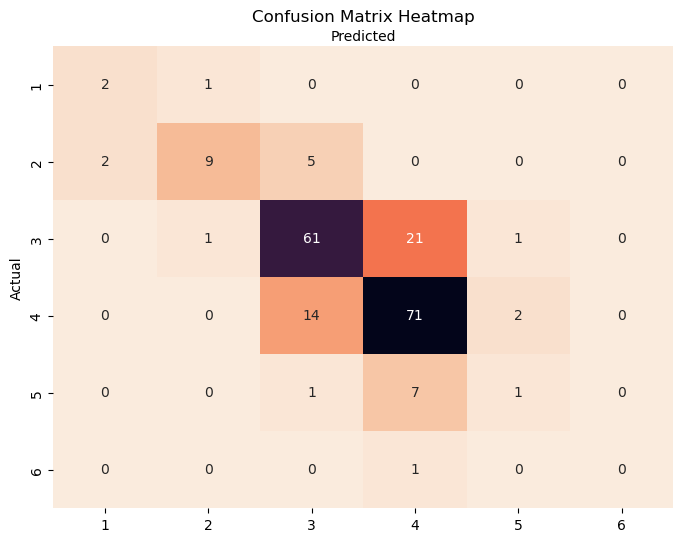

In [82]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', cbar=False, xticklabels = np.arange(1, 7), yticklabels = np.arange(1, 7))

plt.gca().xaxis.set_label_position('top')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The confusion matrix shows that the XGB model accurately predicted the scores of 144 (2+9+61+71+1 = 144) essays.

Now, we calculate the **Quadratic Weighted Kappa (QWK)** score.

In [85]:
qwk_xgb = cohen_kappa_score(y_val, y_pred_xgb, weights='quadratic')
print(f"Quadratic Weighted Kappa (QWK): {qwk_xgb}")

Quadratic Weighted Kappa (QWK): 0.7129735935706085


This shows that the agreement between the actual scores and the predicted scores by the model is approximately 0.712974.

## Kaggle Submission

The file `F78DS-Essay-Features-Submission.csv` contains input variables (essay features) without the output variables (scores). We will use the models previously built to predict the scores from the essays in this file. By doing so, it helps us to evaluate how well the model does when given unseen data. The predicted scores will be saved in a CSV file and submitted in an in-class competition on Kaggle.

To summarize, the QWK scores obtained by each model is as follows:

In [89]:
qwk = [
    ("Gaussian Naive Bayes", qwk_gnb),
    ("Random Forest", qwk_rf),
    ("XGBoost", qwk_xgb),
]

qwk_sorted = sorted(qwk, key=lambda x: x[1], reverse=True) 
#if the list contains tuples like ("Random Forest", 0.71), lambda x: x[1] would extract the second value (e.g., 0.71) from each tuple to compare them during sorting
# reverse=True sorts the qwk scores in descending order

for model, score in qwk_sorted:
    print(f"{model}: {score}")

Random Forest: 0.7229174115123347
XGBoost: 0.7129735935706085
Gaussian Naive Bayes: 0.7001679059726553


From these results, it seems that the Random Forest model has the highest performance however all three models produced results that are reasonably good (>0.7)

In order to make a more robust predictive model, we can use `VotingClassifier`, which is an ensemble method to combine all the models to give us better predictions. By combining them, we can potentially reduce bias and variance, making the predictions more robust.
To do so, first we import `VotingClassifier` and train the ensemble model.

In [92]:
from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(estimators=[
    ('gnb', gnb),
    ('rf', rf),
    ('xgb', xgb)
], voting='hard') 


ensemble.fit(X_train_scaled, y_train)

y_pred_ensemble = ensemble.predict(X_val_scaled)

Again, a **confusion matrix** is used to evaluate the model's performance and a heatmap of the confusion matrix is used for visualisation purposes.

In [94]:
cm = confusion_matrix(y_val, y_pred_ensemble)
cm

array([[ 2,  1,  0,  0,  0,  0],
       [ 3,  9,  4,  0,  0,  0],
       [ 0,  1, 64, 18,  1,  0],
       [ 0,  0, 16, 69,  2,  0],
       [ 0,  0,  1,  7,  1,  0],
       [ 0,  0,  0,  1,  0,  0]], dtype=int64)

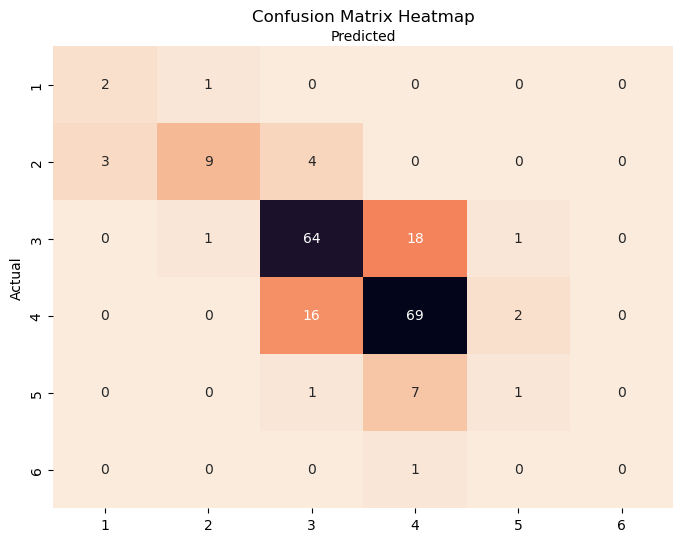

In [95]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', cbar=False, xticklabels = np.arange(1, 7), yticklabels = np.arange(1, 7))

plt.gca().xaxis.set_label_position('top')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Now, we compute the QWK score for the ensemble model.

In [97]:
qwk_ensemble  = cohen_kappa_score(y_val, y_pred_ensemble, weights='quadratic')
print(f"Quadratic Weighted Kappa (QWK): {qwk_ensemble}")

Quadratic Weighted Kappa (QWK): 0.7235182305166753


In [98]:
qwk = [
    ("Gaussian Naive Bayes", qwk_gnb),
    ("Random Forest", qwk_rf),
    ("XGBoost", qwk_xgb),
    ("Ensemble", qwk_ensemble)
]

qwk_sorted = sorted(qwk, key=lambda x: x[1], reverse=True) 

for model, score in qwk_sorted:
    print(f"{model}: {score}")

Ensemble: 0.7235182305166753
Random Forest: 0.7229174115123347
XGBoost: 0.7129735935706085
Gaussian Naive Bayes: 0.7001679059726553


Based on the QWK scores of each model, we can see that the ensemble model recorded the highest agreement between the actual scores and the predicted ascores.

Now we use the ensemble model to predict the essay scores for the essays found in `F78DS-Essay-Features-Submission.csv`.

In [101]:
test_data_kaggle = pd.read_csv('F78DS-Essay-Features-Submission.csv')

test_data = test_data_kaggle.drop(['punctuations', 'POS/total_words', 'questions', 'prompt_words/total_words', 'essayid', 'avg_word_sentence'], axis=1)

test_data_scaled = scaler.transform(test_data)

test_predictions = rf.predict(test_data_scaled) 

The predictions are then saved in a CSV file and submitted in Kaggle.

In [103]:
submission = pd.DataFrame({
    'essayid': test_data_kaggle['essayid'],
    'score': test_predictions
})
submission.to_csv('H00488258-ReneeLimEeLing-26.csv', index=False)

print("\nTest predictions saved to 'H00488258-ReneeLimEeLing-26.csv'")


Test predictions saved to 'H00488258-ReneeLimEeLing-26.csv'
